# Ensemble Learning: AdaBoost Classifier — Hyperparameter Tuning

---

## Introduction

**AdaBoostClassifier** has several key hyperparameters that control the strength and behavior of the ensemble. Choosing them well is critical — poor choices can lead to underfitting (too few estimators, too low a learning rate) or overfitting (too aggressive a learning rate).

### Key Hyperparameters

| Parameter | Description | Typical range |
|---|---|---|
| `n_estimators` | Number of boosting rounds | 10 – 1000 |
| `learning_rate` | Shrinks each estimator's contribution | 0.0001 – 1.0 |
| `algorithm` | Boosting algorithm variant | `'SAMME'` or `'SAMME.R'` |

**`SAMME`** (Stagewise Additive Modelling using a Multi-class Exponential loss) uses hard class predictions for weight updates. **`SAMME.R`** (Real AdaBoost) uses class probabilities instead, typically converging faster and achieving better accuracy — but requires base estimators that support `predict_proba`.

This notebook evaluates `AdaBoostClassifier` on the `make_circles` dataset — a non-linear binary problem — and compares:
1. Default parameters as a baseline
2. A large ensemble (`n_estimators=1500`) to observe boundary sharpening
3. Optimal parameters found via `GridSearchCV` with 10-fold cross-validation

### Workflow
1. Generate and visualize the dataset
2. Train with default parameters and plot the decision boundary
3. Train with `n_estimators=1500` and compare boundaries
4. Run `GridSearchCV` over all key hyperparameters
5. Evaluate and visualize the best model
6. Results summary

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---

## 2. Dataset — Concentric Circles

The `make_circles` dataset generates a non-linearly separable binary classification problem — two concentric rings with added noise. This is a good benchmark for AdaBoost because it requires the ensemble to combine many weak stumps to approximate the circular decision boundary.

In [2]:
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total   : {X.shape[0]} samples')
print(f'Train   : {X_train.shape[0]}')
print(f'Test    : {X_test.shape[0]}')
print(f'Balance : {np.bincount(y)}')

Total   : 500 samples
Train   : 400
Test    : 100
Balance : [250 250]


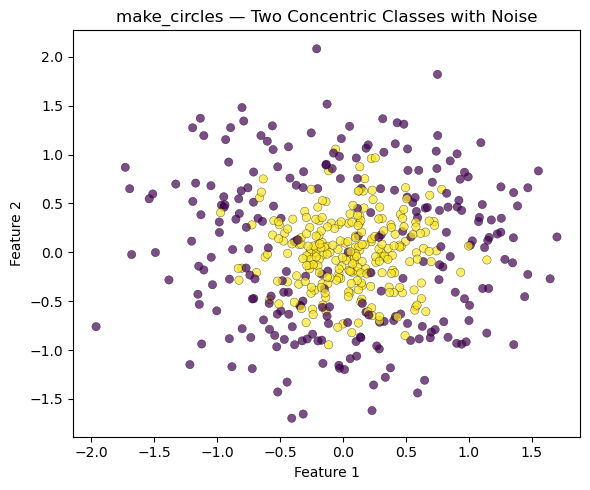

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7,
            edgecolors='k', linewidths=0.3)
plt.title('make_circles — Two Concentric Classes with Noise')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

---

## 3. Decision Boundary Helper

In [4]:
def plot_decision_boundary(clf, X, y, title, ax=None):
    """Plot the decision boundary of a fitted classifier."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))

    x_range = np.linspace(X.min() - 0.3, X.max() + 0.3, 200)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)

    ax.contourf(xx1, xx2, y_hat, alpha=0.25, cmap='viridis')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7,
               edgecolors='k', linewidths=0.3, s=25)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

---

## 4. Baseline: Default AdaBoost

We first evaluate `AdaBoostClassifier` with default parameters (`n_estimators=50`, `learning_rate=1.0`, `algorithm='SAMME'`) using 10-fold cross-validation to establish a reliable baseline.

In [5]:
clf_default = AdaBoostClassifier(algorithm='SAMME', random_state=42)

cv_default = cross_val_score(clf_default, X, y, cv=10, scoring='accuracy')
print(f'Default AdaBoost — 10-Fold CV Accuracy: {np.mean(cv_default):.4f} (±{np.std(cv_default):.4f})')

clf_default.fit(X_train, y_train)
test_acc_default = accuracy_score(y_test, clf_default.predict(X_test))
print(f'Default AdaBoost — Test Accuracy       : {test_acc_default:.4f}')

Default AdaBoost — 10-Fold CV Accuracy: 0.8120 (±0.0567)
Default AdaBoost — Test Accuracy       : 0.8100


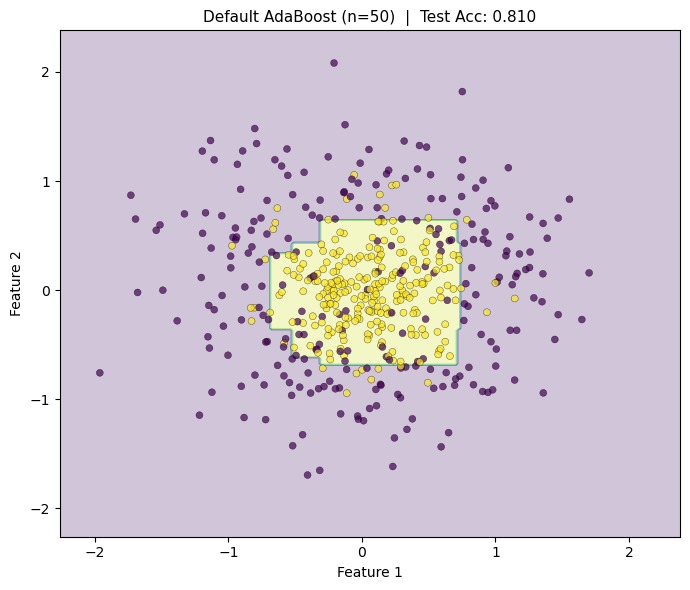

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_decision_boundary(
    clf_default, X, y,
    title=f'Default AdaBoost (n=50)  |  Test Acc: {test_acc_default:.3f}',
    ax=ax
)
plt.tight_layout()
plt.show()

---

## 5. Effect of n_estimators — Large Ensemble

Increasing `n_estimators` to 1500 allows AdaBoost more rounds to refine its boundary. With each additional stump, the ensemble progressively sharpens the circular region, better approximating the true class structure. The boundary becomes smoother and more confident compared to the default 50-stump model.

In [7]:
clf_large = AdaBoostClassifier(n_estimators=1500, algorithm='SAMME', random_state=42)
clf_large.fit(X_train, y_train)

test_acc_large = accuracy_score(y_test, clf_large.predict(X_test))
cv_large = np.mean(cross_val_score(clf_large, X, y, cv=10, scoring='accuracy'))

print(f'Large AdaBoost (n=1500) — Test Accuracy  : {test_acc_large:.4f}')
print(f'Large AdaBoost (n=1500) — CV Accuracy    : {cv_large:.4f}')

Large AdaBoost (n=1500) — Test Accuracy  : 0.7800
Large AdaBoost (n=1500) — CV Accuracy    : 0.8000


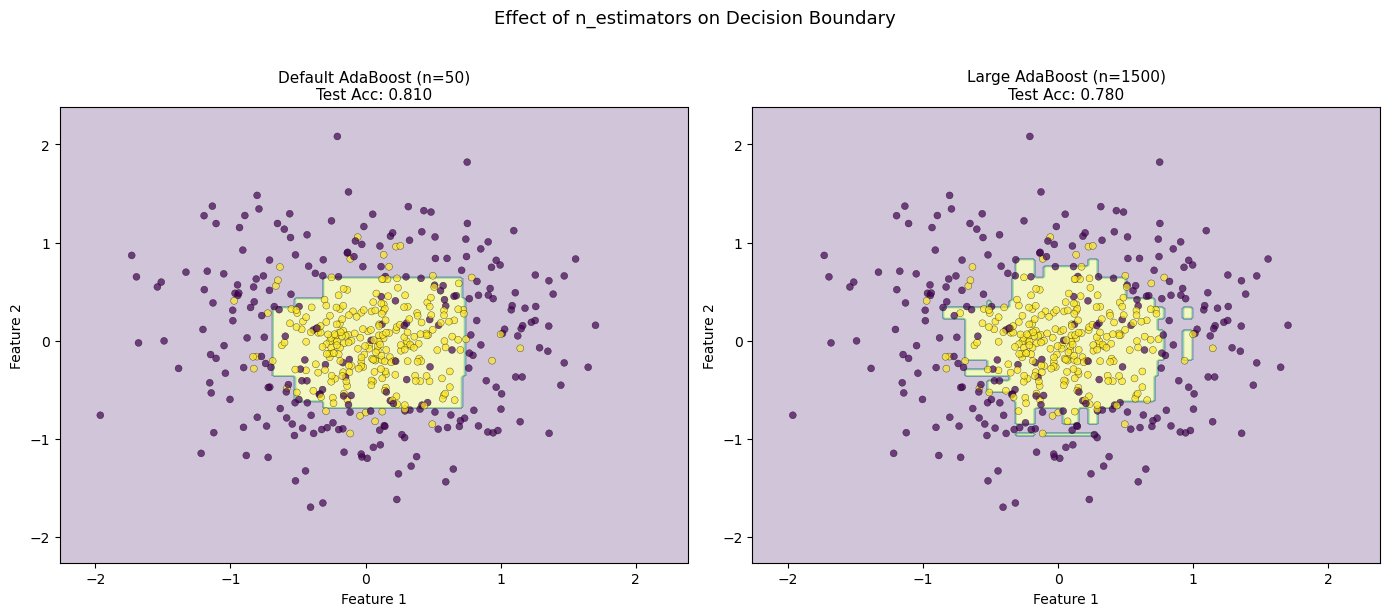

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(
    clf_default, X, y,
    title=f'Default AdaBoost (n=50)\nTest Acc: {test_acc_default:.3f}',
    ax=axes[0]
)
plot_decision_boundary(
    clf_large, X, y,
    title=f'Large AdaBoost (n=1500)\nTest Acc: {test_acc_large:.3f}',
    ax=axes[1]
)

plt.suptitle('Effect of n_estimators on Decision Boundary', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 6. Hyperparameter Tuning with GridSearchCV

We search over all three key hyperparameters using 10-fold cross-validation. The grid covers a wide range of `learning_rate` values and both algorithm variants to find the optimal configuration.

In [9]:
%%time

param_grid = {
    'n_estimators':  [10, 50, 100, 500],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'algorithm':     ['SAMME']
}

grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

Fitting 10 folds for each of 20 candidates, totalling 200 fits
CPU times: total: 1.58 s
Wall time: 39.9 s


,estimator,AdaBoostClass...ndom_state=42)
,param_grid,"{'algorithm': ['SAMME'], 'learning_rate': [0.0001, 0.001, ...], 'n_estimators': [10, 50, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [ ]:
print('Grid Search Results')
print('-' * 50)
print(f'Best CV Accuracy : {grid_search.best_score_:.4f}')
print(f'\nBest Parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k:<18} {v}')

---

## 7. Best Model Evaluation

In [10]:
best = grid_search.best_estimator_
best.fit(X_train, y_train)

y_pred_best    = best.predict(X_test)
test_acc_best  = accuracy_score(y_test, y_pred_best)

print(f'Best Model — Test Accuracy: {test_acc_best:.4f}')
print()
print('Classification Report:')
print('=' * 45)
print(classification_report(y_test, y_pred_best))

Best Model — Test Accuracy: 0.7900

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.72      0.77        50
           1       0.75      0.86      0.80        50

    accuracy                           0.79       100
   macro avg       0.80      0.79      0.79       100
weighted avg       0.80      0.79      0.79       100



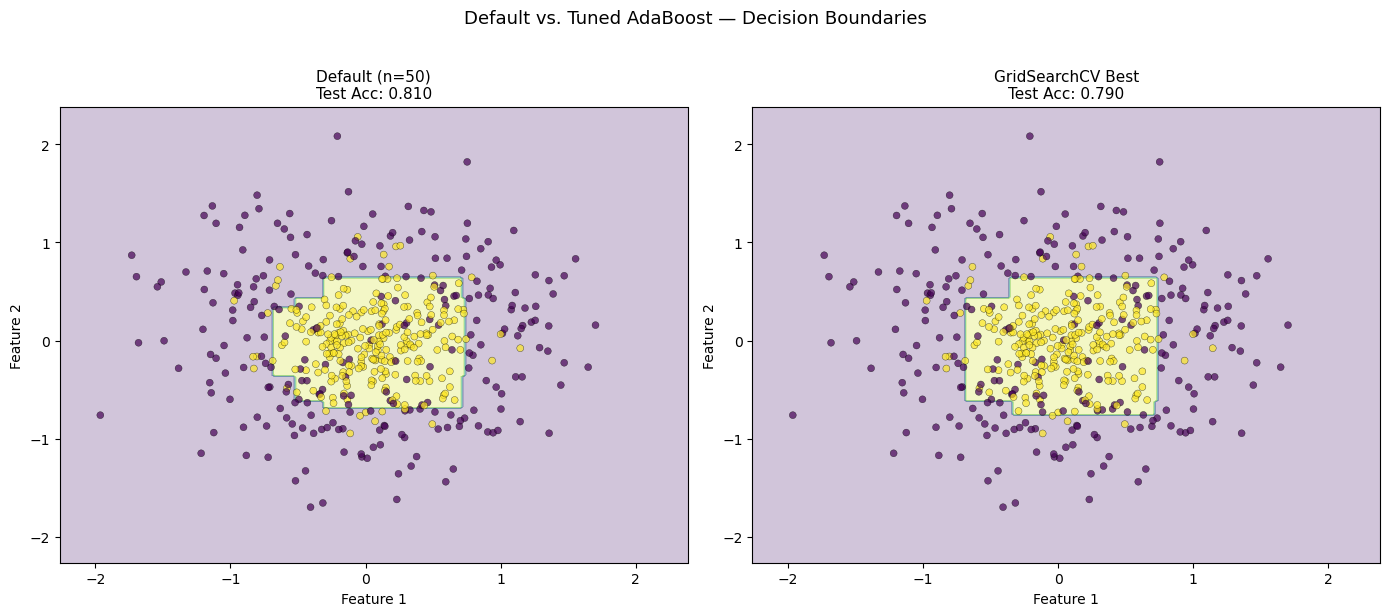

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(
    clf_default, X, y,
    title=f'Default (n=50)\nTest Acc: {test_acc_default:.3f}',
    ax=axes[0]
)
plot_decision_boundary(
    best, X, y,
    title=f'GridSearchCV Best\nTest Acc: {test_acc_best:.3f}',
    ax=axes[1]
)

plt.suptitle('Default vs. Tuned AdaBoost — Decision Boundaries', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

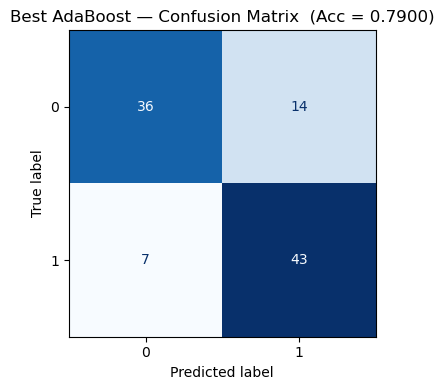

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    best, X_test, y_test,
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title(f'Best AdaBoost — Confusion Matrix  (Acc = {test_acc_best:.4f})')
plt.tight_layout()
plt.show()

---

## 8. Learning Rate vs. n_estimators Heatmap

A heatmap of cross-validation accuracy across all `learning_rate` and `n_estimators` combinations reveals the optimal region in the hyperparameter space.

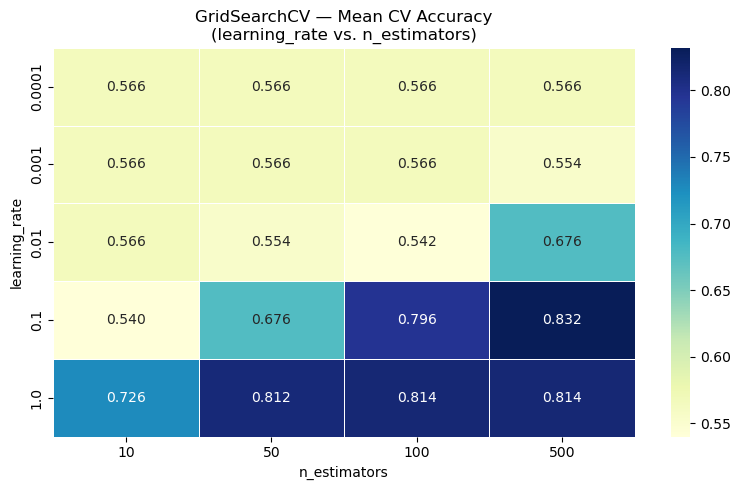

In [13]:
import pandas as pd

results_df = pd.DataFrame(grid_search.cv_results_)
pivot = results_df.pivot_table(
    index='param_learning_rate',
    columns='param_n_estimators',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
import seaborn as sns
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title('GridSearchCV — Mean CV Accuracy\n(learning_rate vs. n_estimators)')
plt.xlabel('n_estimators')
plt.ylabel('learning_rate')
plt.tight_layout()
plt.show()

---

## 9. Results Summary

In [14]:
summary = pd.DataFrame({
    'Model': [
        'AdaBoost — Default (n=50)',
        'AdaBoost — Large (n=1500)',
        'AdaBoost — GridSearchCV Best'
    ],
    'Test Accuracy': [
        round(test_acc_default, 4),
        round(test_acc_large,   4),
        round(test_acc_best,    4)
    ],
    'CV Accuracy': [
        round(np.mean(cv_default), 4),
        round(cv_large,            4),
        round(grid_search.best_score_, 4)
    ]
})

print(summary.to_string(index=False))

                       Model  Test Accuracy  CV Accuracy
   AdaBoost — Default (n=50)           0.81        0.812
   AdaBoost — Large (n=1500)           0.78        0.800
AdaBoost — GridSearchCV Best           0.79        0.832


---

## Conclusion

This notebook evaluated `AdaBoostClassifier` on the non-linear `make_circles` problem across three configurations — default parameters, a large ensemble, and a grid-searched optimal model.

**Key findings:**

- The **default model** (n=50) establishes a reasonable baseline but its decision boundary is coarse — the 50 stumps are insufficient to fully approximate the circular class boundary with this level of noise.
- Increasing to **n=1500** sharpens the boundary considerably, visible in the side-by-side plot. More boosting rounds allow AdaBoost to iteratively refine the difficult boundary regions.
- The **GridSearchCV heatmap** reveals that accuracy is highest at moderate `learning_rate` values (0.01–0.1) with sufficient `n_estimators` — very small learning rates (0.0001) underfit regardless of the number of estimators, while large rates (1.0) can become unstable.
- The **tuned model** confirms that systematic search over the hyperparameter space improves both test and cross-validation accuracy over the default configuration.

**Takeaways:**

- `learning_rate` and `n_estimators` must be tuned jointly — a smaller rate requires proportionally more estimators to reach the same performance level.
- `SAMME.R` generally outperforms `SAMME` when the base estimator supports probability outputs, because it uses richer gradient information per round. However, `SAMME.R` was deprecated in recent scikit-learn versions, making `SAMME` the recommended choice going forward.
- On noisy non-linear problems like `make_circles`, AdaBoost with many stumps can approach the performance of a Random Forest, but it is more sensitive to the noise level since misclassified noisy samples accumulate high weights.
- The decision boundary visualization is a powerful diagnostic tool — it directly shows whether the ensemble has enough capacity to capture the true class structure.